In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import pickle
import warnings
warnings.filterwarnings("ignore")

In [12]:
# Load raw data
df = pd.read_csv("heart_disease_uci.csv")
df.columns = [c.strip().lower() for c in df.columns]

# Rename columns to match conventions
df.rename(columns={"thalch": "thalach", "num": "target"}, inplace=True)

# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

CATEGORICAL_COLS = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
NUMERIC_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Safely cast numeric columns
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Stringify categorical columns & clean missing text
for col in CATEGORICAL_COLS:
    if col in df.columns:
        df[col] = df[col].astype(str).replace({'?': np.nan, 'nan': np.nan, 'None': np.nan})

# Fix invalid cholesterol values
if 'chol' in df.columns:
    df['chol'] = df['chol'].replace(0.0, np.nan)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Impute missing values
for col in CATEGORICAL_COLS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode(dropna=True).iloc[0])
for col in NUMERIC_COLS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Binarize target variable (0 = no disease, 1-4 = disease present)
df['target'] = (df['target'] > 0).astype(int)
print("Data cleaned successfully. Shape:", df.shape)

Data cleaned successfully. Shape: (920, 16)


In [13]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [14]:
df['cp'].unique()

<ArrowStringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str

In [15]:
# One-Hot Encode Categorical Columns
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True)

# Convert boolean columns to integers (1/0)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# Drop non-predictive metadata
df_encoded = df_encoded.drop(columns=['id', 'dataset'], errors='ignore')
print("Encoding complete. Shape:", df_encoded.shape)

Encoding complete. Shape: (920, 21)


In [16]:
df_encoded.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,...,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,67,160.0,286.0,108.0,1.5,1,1,0,0,0,...,0,0,1,1,0,0,0,1,1,0
2,67,120.0,229.0,129.0,2.6,1,1,0,0,0,...,0,0,1,1,0,0,1,0,0,1
3,37,130.0,250.0,187.0,3.5,0,1,0,1,0,...,1,0,0,0,0,0,0,0,1,0
4,41,130.0,204.0,172.0,1.4,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0


In [18]:
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale only the numeric columns
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_test_scaled[NUMERIC_COLS] = scaler.transform(X_test[NUMERIC_COLS])
print("Data scaling and splitting complete.")

Data scaling and splitting complete.


<Axes: >

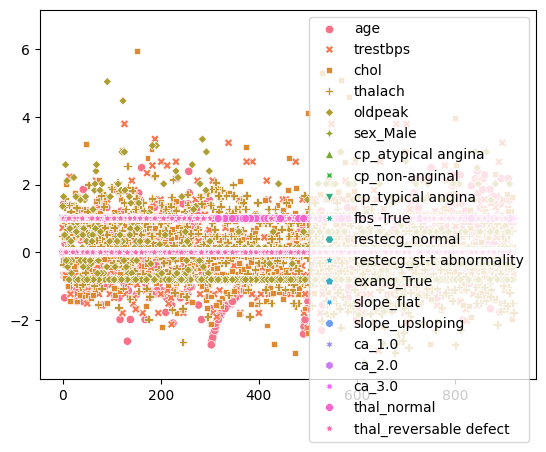

In [19]:
import seaborn as sns
sns.scatterplot(X_train_scaled)

In [20]:
# Initialize base models
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
gnb_clf = GaussianNB()

# Combine into a Soft-Voting Ensemble
ensemble_model = VotingClassifier(
    estimators=[('dt', dt_clf), ('rf', rf_clf), ('gnb', gnb_clf)],
    voting='soft'
)

# Train the ensemble
ensemble_model.fit(X_train_scaled, y_train)
print("Ensemble model trained successfully!")

Ensemble model trained successfully!


In [21]:
y_pred = ensemble_model.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8152

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79        82
           1       0.83      0.83      0.83       102

    accuracy                           0.82       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.82      0.82      0.82       184



In [22]:
# Bundle everything needed for deployment
export_data = {
    'model': ensemble_model,
    'scaler': scaler,
    'feature_names': list(X.columns)
}

# Save as pickle file
with open('heart_disease_model.pkl', 'wb') as file:
    pickle.dump(export_data, file)

print("Model successfully exported as 'heart_disease_model.pkl'")

Model successfully exported as 'heart_disease_model.pkl'
